# Demo notebook for roughness estimation

### Imports

In [26]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.constants import CKPT_FOLDER
from src.generate import generate_Z, generate_OU, create_data, load_data
from src.models import CNN, LSTM
from src.utils import split_and_load_data, split_and_load_sliding_windows

from tools.train import train
from tools.test import compute_mae, draw_predictions, ou_test

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device '+str(device))

Using device cuda


### Data visualization

We simulate a stochastic process driven by a Hurst parameter $H \in (0, 1)$. It is defined by the following integral with respect to a standard Brownian motion $W_u$:
$$Z_t = \eta \sqrt{2H }\int_0^t (t-u)^{H-\frac{1}{2}} dW_u$$

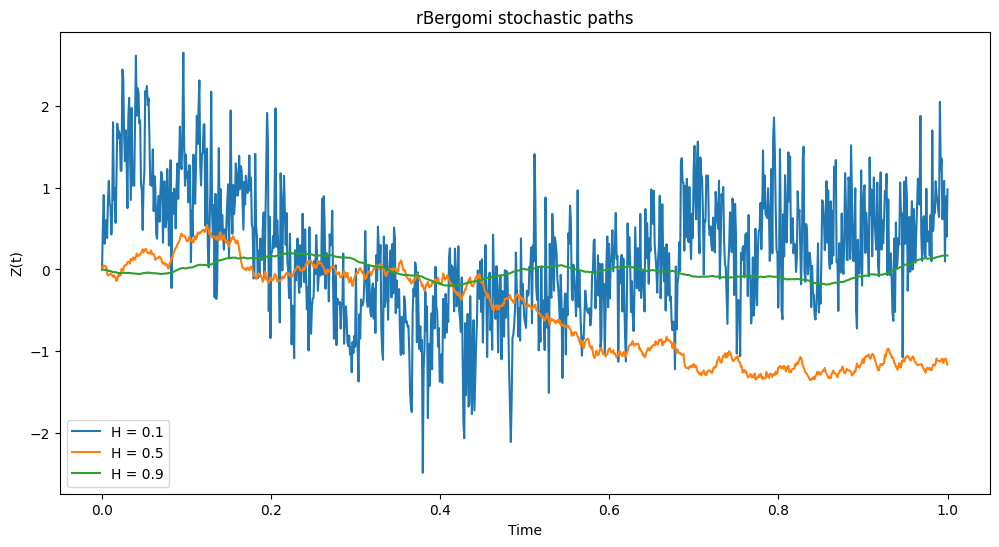

In [3]:
n_points = 1000
eta = 1
T = 1
time = np.linspace(0, 1, n_points)

plt.figure(figsize=(12,6))
for h in [0.1, 0.5, 0.9]:
    plt.plot(time, generate_Z(h, eta, 1, n_points, T)[0], label=f"H = {h}")
plt.title("rBergomi stochastic paths")
plt.xlabel("Time")
plt.ylabel("Z(t)")
plt.legend()
plt.show()

For $H < 0.5$, the increments of $Z$ are negatively correlated, and for $H > 0.5$, they are positively correlated. Increments are independant when $H=0.5$.

In [4]:
n_samples = 40000
n_H = 2000
# create_data(n_samples, n_points, T, n_H)
Z, H = load_data(n_samples, n_points)

Loading data...


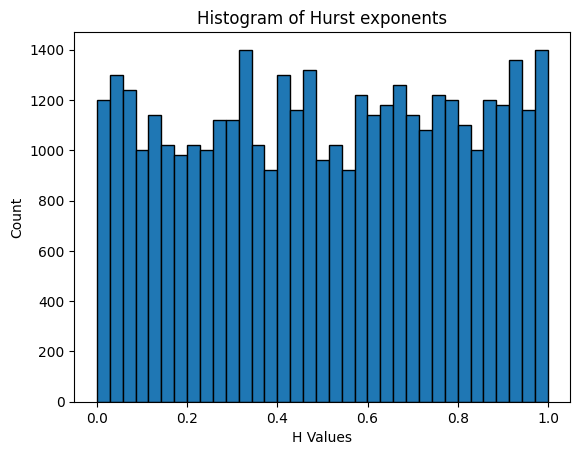

In [5]:
plt.hist(H, bins='auto', edgecolor='black')
plt.xlabel('H Values')
plt.ylabel('Count')
plt.title('Histogram of Hurst exponents')
plt.show()

In [6]:
batch_size = 512
train_loader, val_loader, test_loader = split_and_load_data(Z, H, batch_size=batch_size)

Train segments: 28000 | Val segments: 4000 | Test segments: 8000


### CNN Prediction

In [7]:
cnn = CNN(n_points).to(device=device)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

In [8]:
ckpt_prefix = "cnn_"
n_epochs = 60
train_losses, val_losses = train(cnn, train_loader, n_epochs, optimizer, criterion, val_loader=val_loader, ckpt_prefix=ckpt_prefix, device=device)

Model saved !
Epoch: 1 | Losses: {train_loss: 0.04625, val_loss: 0.06237}
Model saved !
Epoch: 2 | Losses: {train_loss: 0.01055, val_loss: 0.05328}
Model saved !
Epoch: 3 | Losses: {train_loss: 0.00812, val_loss: 0.03372}
Epoch: 4 | Losses: {train_loss: 0.00683, val_loss: 0.03664}
Model saved !
Epoch: 5 | Losses: {train_loss: 0.00554, val_loss: 0.02975}
Model saved !
Epoch: 6 | Losses: {train_loss: 0.00579, val_loss: 0.02162}
Epoch: 7 | Losses: {train_loss: 0.00548, val_loss: 0.02309}
Epoch: 8 | Losses: {train_loss: 0.00465, val_loss: 0.02562}
Model saved !
Epoch: 9 | Losses: {train_loss: 0.00463, val_loss: 0.02018}
Model saved !
Epoch: 10 | Losses: {train_loss: 0.00417, val_loss: 0.01614}
Epoch: 11 | Losses: {train_loss: 0.00375, val_loss: 0.01758}
Epoch: 12 | Losses: {train_loss: 0.00366, val_loss: 0.01640}
Model saved !
Epoch: 13 | Losses: {train_loss: 0.00359, val_loss: 0.01460}
Epoch: 14 | Losses: {train_loss: 0.00357, val_loss: 0.01901}
Epoch: 15 | Losses: {train_loss: 0.00366, v

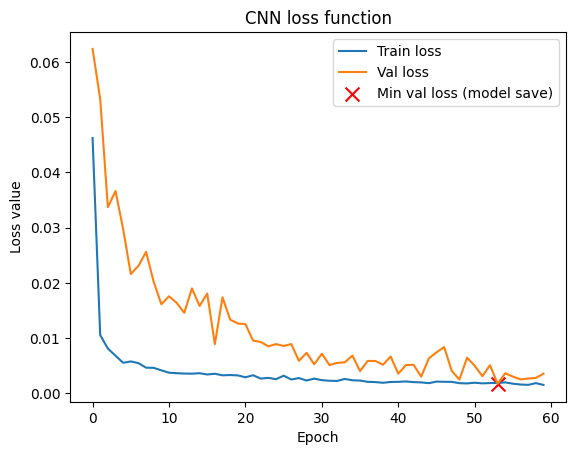

In [9]:
plt.plot(range(n_epochs), train_losses, label="Train loss")
plt.plot(range(n_epochs), val_losses, label="Val loss")
min_val_loss_idx = np.argmin(val_losses)
plt.scatter(min_val_loss_idx, val_losses[min_val_loss_idx], color='red', marker='x', s=100, label='Min val loss (model save)')
plt.legend()
plt.title('CNN loss function')
plt.xlabel('Epoch')
plt.ylabel('Loss value')
plt.show()

In [10]:
cnn.load_state_dict(torch.load(os.path.join(CKPT_FOLDER, ckpt_prefix + "best_model.pt"), weights_only=True, map_location=device))
compute_mae(cnn, test_loader, device=device)

Model Test MAE: 0.0268


### Robustness test on Ornstein-Uhlenbeck processes

An Ornstein-Uhlenbeck process is a mean-reverting stochastic process described by the SDE: $dX_t = \theta (\mu - X_t)dt + \sigma dW_t$, where $\theta$ is the mean reversion speed, $\mu$ is the long-term mean, $\sigma$ is the volatility, and $W_t$ is a standard Brownian motion.

In [11]:
ou = torch.tensor(generate_OU(X0=0, mu=1, theta=1, sigma=1, n_paths=10000, n_points=n_points, T=T), dtype=torch.float32)

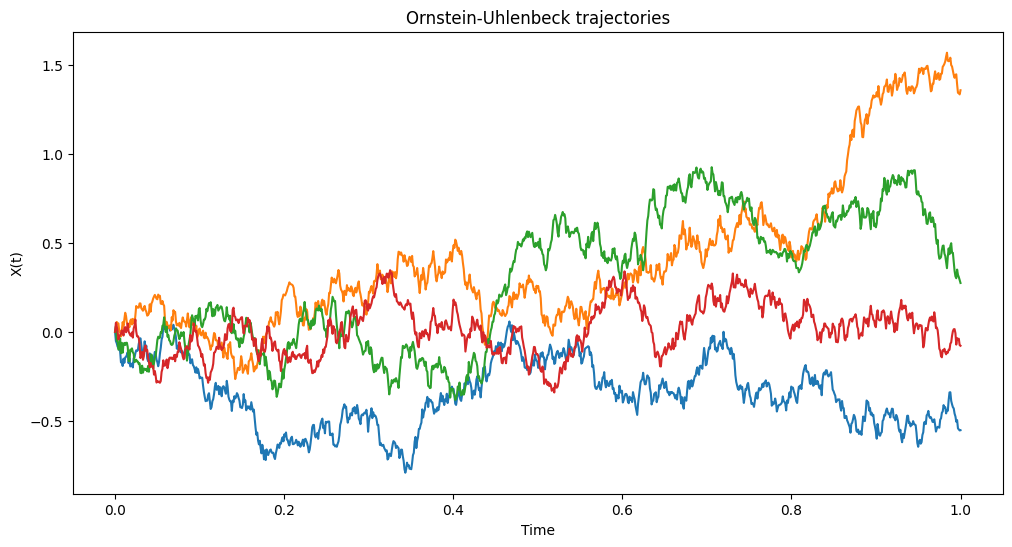

In [12]:
plt.figure(figsize=(12,6))
plt.plot(time, ou.T[:, :4])
plt.title("Ornstein-Uhlenbeck trajectories")
plt.xlabel("Time")
plt.ylabel("X(t)")
plt.show()

The Ornstein-Uhlenbeck process is $\gamma$-Hölder continuous for all $\gamma \in (0, 0.5)$. We expect our model to predict $0.5$ on these trajectories.

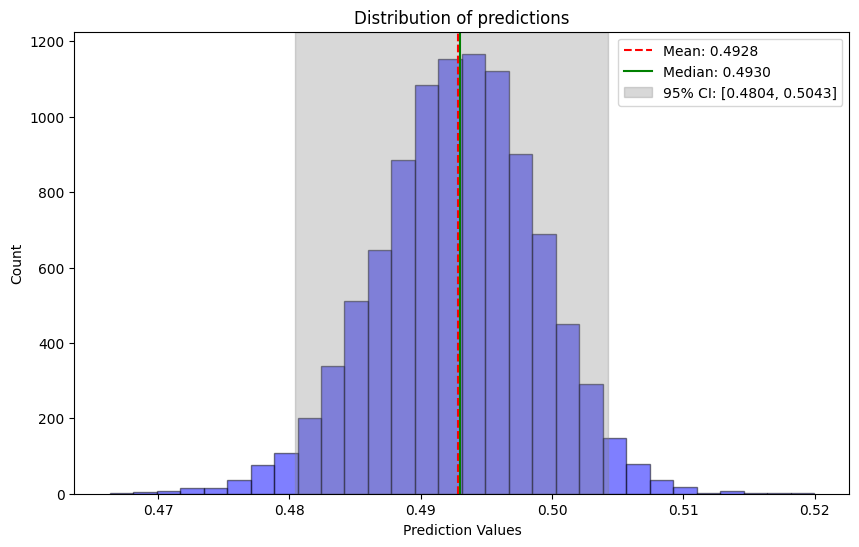

In [13]:
ou_test(cnn, ou_paths=ou, device=device)

### LSTM Prediction

In [14]:
window_size = 100
stride = 10
train_loader_window, val_loader_window, test_loader_window = split_and_load_sliding_windows(Z, H, window_size=window_size, stride=stride, batch_size=batch_size)

Train segments: 2548000 | Val segments: 364000 | Test segments: 728000


In [15]:
lstm = LSTM(num_layers=2, window_size=window_size, stride=stride).to(device=device)
optimizer = torch.optim.Adam(lstm.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

In [16]:
ckpt_prefix = "lstm_"
n_epochs = 40
train_losses, val_losses = train(lstm, train_loader_window, n_epochs, optimizer, criterion, val_loader=val_loader_window, ckpt_prefix=ckpt_prefix, device=device)

Model saved !
Epoch: 1 | Losses: {train_loss: 0.01759, val_loss: 0.00953}
Model saved !
Epoch: 2 | Losses: {train_loss: 0.00990, val_loss: 0.00668}
Model saved !
Epoch: 3 | Losses: {train_loss: 0.00732, val_loss: 0.00588}
Model saved !
Epoch: 4 | Losses: {train_loss: 0.00519, val_loss: 0.00493}
Model saved !
Epoch: 5 | Losses: {train_loss: 0.00398, val_loss: 0.00382}
Model saved !
Epoch: 6 | Losses: {train_loss: 0.00376, val_loss: 0.00369}
Model saved !
Epoch: 7 | Losses: {train_loss: 0.00367, val_loss: 0.00362}
Model saved !
Epoch: 8 | Losses: {train_loss: 0.00361, val_loss: 0.00357}
Model saved !
Epoch: 9 | Losses: {train_loss: 0.00357, val_loss: 0.00352}
Epoch: 10 | Losses: {train_loss: 0.00355, val_loss: 0.00354}
Model saved !
Epoch: 11 | Losses: {train_loss: 0.00352, val_loss: 0.00349}
Epoch: 12 | Losses: {train_loss: 0.00351, val_loss: 0.00363}
Model saved !
Epoch: 13 | Losses: {train_loss: 0.00350, val_loss: 0.00346}
Epoch: 14 | Losses: {train_loss: 0.00349, val_loss: 0.00351}
E

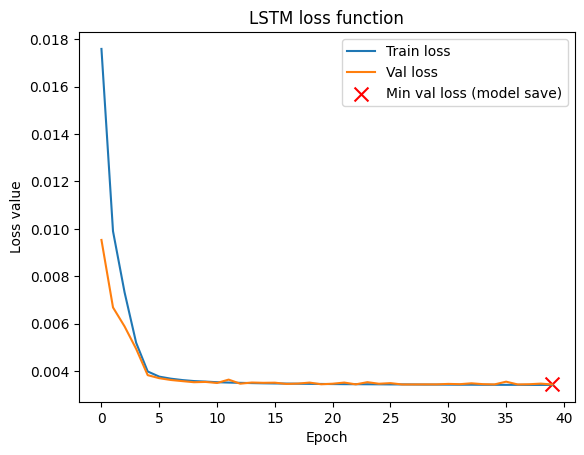

In [17]:
plt.plot(range(n_epochs), train_losses, label="Train loss")
plt.plot(range(n_epochs), val_losses, label="Val loss")
min_val_loss_idx = np.argmin(val_losses)
plt.scatter(min_val_loss_idx, val_losses[min_val_loss_idx], color='red', marker='x', s=100, label='Min val loss (model save)')
plt.legend()
plt.title('LSTM loss function')
plt.xlabel('Epoch')
plt.ylabel('Loss value')
plt.show()

In [ ]:
lstm.load_state_dict(torch.load(os.path.join(CKPT_FOLDER, ckpt_prefix + "best_model.pt"), weights_only=True, map_location=device))
compute_mae(lstm, test_loader_window, device=device) # Warning : We cannot compare this number to the CNN MAE because the test_loader contains smaller windows of data.

Model Test MAE: 0.0450


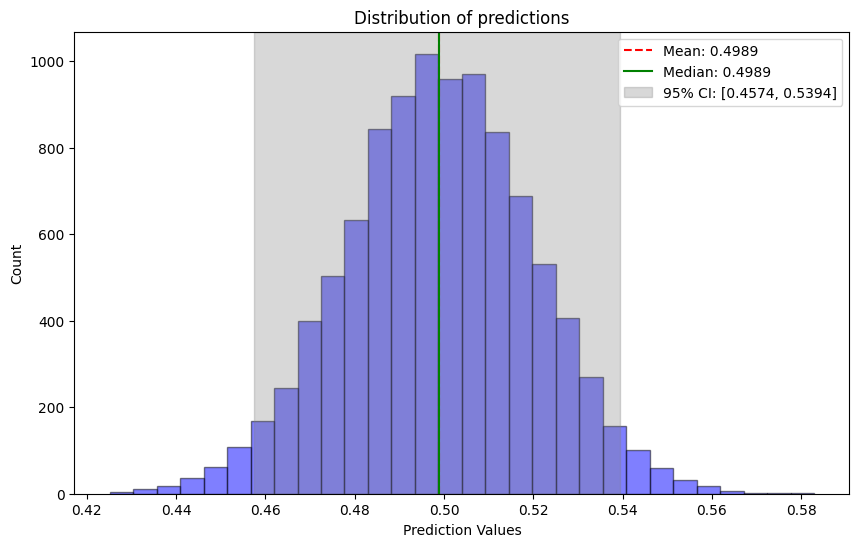

In [19]:
ou_test(lstm, ou_paths=ou, device=device)

### CNN vs. LSTM

Generating paths ...


100%|██████████| 11/11 [00:04<00:00,  2.38it/s]


Predicting with model 1 (CNN)...


100%|██████████| 11/11 [00:00<00:00, 24.83it/s]


Predicting with model 2 (LSTM)...


100%|██████████| 11/11 [00:02<00:00,  4.34it/s]


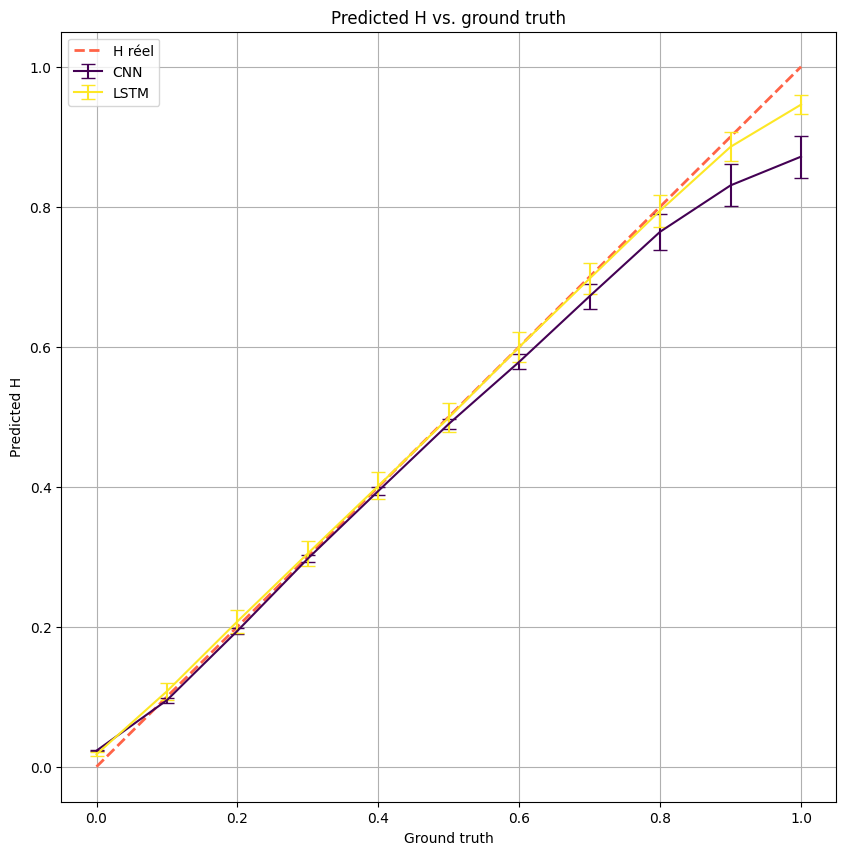

In [27]:
draw_predictions(models=[cnn, lstm], model_labels=["CNN", "LSTM"], paths_per_H=1000, n_points=n_points, T=T, device=device)